<a href="https://colab.research.google.com/github/souhaylelhammadi/Introduction-l-informatique-quantique/blob/main/TP3_Mini_Batch_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 : Mini-Batch Gradient Descent

## Objectifs
- Comprendre le principe du **Mini-Batch Gradient Descent**
- Implémenter l'algorithme **from scratch**
- Comparer avec **Batch GD** et **SGD** (TP1 & TP2)
- Étudier l'effet de la **taille du mini-batch** sur la convergence
- Optimiser une fonction **simple** et une fonction **complexe**
- Appliquer à la **classification** et évaluer les performances

---

## 1. Théorie

### Principe
Le **Mini-Batch Gradient Descent** est un compromis entre Batch GD et SGD. À chaque itération, on calcule le gradient sur un **sous-ensemble** (mini-batch) de $B$ exemples :

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{1}{B} \sum_{i \in \mathcal{B}_t} \nabla J_i(\theta_t)$$

où $\mathcal{B}_t$ est le mini-batch de taille $B$ à l'itération $t$.

### Cas particuliers
| Taille du batch $B$ | Méthode |
|---|---|
| $B = N$ (tout le dataset) | **Batch GD** |
| $B = 1$ | **SGD** |
| $1 < B < N$ | **Mini-Batch GD** |

### Avantages
- **Plus rapide** que Batch GD (pas besoin de tout le dataset)
- **Plus stable** que SGD (moyenne sur $B$ exemples réduit la variance)
- Exploite le **parallélisme matériel** (GPU, vectorisation)
- Tailles typiques : $B \in \{16, 32, 64, 128, 256\}$

### Inconvénients
- Hyperparamètre supplémentaire : la **taille du batch**
- Toujours un peu de bruit (mais contrôlable)

## 2. Imports et Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 3. Implémentation du Mini-Batch GD pour l'optimisation de fonctions

Pour l'optimisation de fonctions mathématiques, on simule l'effet des mini-batches en ajoutant du bruit au gradient, avec une **variance inversement proportionnelle** à la taille du batch (plus le batch est grand, moins il y a de bruit).

In [2]:
def mini_batch_gd_optimize(gradient_func, x_init, learning_rate=0.01, n_iterations=1000,
                            batch_size=32, total_samples=1000, tol=1e-8):
    """
    Mini-Batch Gradient Descent pour l'optimisation de fonctions.
    La variance du bruit est inversement proportionnelle à la taille du batch.

    Paramètres:
    -----------
    batch_size : int
        Taille du mini-batch. Contrôle le compromis bruit/stabilité.
    total_samples : int
        Nombre total d'échantillons simulés (pour calibrer le bruit)
    """
    x = np.array(x_init, dtype=float)
    path = [x.copy()]

    # Le bruit diminue quand batch_size augmente
    # Variance ~ 1/batch_size (par le théorème central limite)
    noise_scale = 1.0 / np.sqrt(batch_size)

    for i in range(n_iterations):
        # Gradient avec bruit proportionnel à 1/sqrt(batch_size)
        grad = gradient_func(x)
        noisy_grad = grad + noise_scale * np.random.randn(*grad.shape)

        if np.linalg.norm(grad) < tol:
            print(f"Convergence à l'itération {i}")
            break

        x = x - learning_rate * noisy_grad
        path.append(x.copy())

    return path

def batch_gradient_descent(gradient_func, x_init, learning_rate=0.01, n_iterations=1000, tol=1e-8):
    """Batch GD pour comparaison"""
    x = np.array(x_init, dtype=float)
    path = [x.copy()]
    for i in range(n_iterations):
        grad = gradient_func(x)
        if np.linalg.norm(grad) < tol:
            break
        x = x - learning_rate * grad
        path.append(x.copy())
    return path

def sgd_optimize(gradient_func, x_init, learning_rate=0.01, n_iterations=1000, noise_scale=1.0):
    """SGD pour comparaison (bruit maximal, batch_size=1)"""
    x = np.array(x_init, dtype=float)
    path = [x.copy()]
    for i in range(n_iterations):
        grad = gradient_func(x)
        noisy_grad = grad + noise_scale * np.random.randn(*grad.shape)
        x = x - learning_rate * noisy_grad
        path.append(x.copy())
    return path

## 4. Fonction Simple : Fonction Quadratique

$$f(x, y) = x^2 + y^2$$

In [3]:
def f_simple(x):
    return x[0]**2 + x[1]**2

def grad_simple(x):
    return np.array([2*x[0], 2*x[1]])

In [4]:
x_init = np.array([4.0, 3.0])
n_iter = 200
lr = 0.05

# Les trois méthodes
path_bgd = batch_gradient_descent(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter)
path_sgd = sgd_optimize(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter, noise_scale=1.0)
path_mb32 = mini_batch_gd_optimize(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter, batch_size=32)
path_mb128 = mini_batch_gd_optimize(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter, batch_size=128)

print(f"{'Méthode':<20} {'Point final':>25} {'f finale':>12}")
print("-" * 60)
for name, path in [('Batch GD', path_bgd), ('SGD (B=1)', path_sgd),
                     ('Mini-batch (B=32)', path_mb32), ('Mini-batch (B=128)', path_mb128)]:
    print(f"{name:<20} [{path[-1][0]:>8.4f}, {path[-1][1]:>8.4f}] {f_simple(path[-1]):>12.6f}")

Méthode                            Point final     f finale
------------------------------------------------------------
Batch GD             [  0.0000,   0.0000]     0.000000
SGD (B=1)            [  0.0414,  -0.1850]     0.035931
Mini-batch (B=32)    [ -0.0064,  -0.0067]     0.000087
Mini-batch (B=128)   [  0.0097,  -0.0064]     0.000135


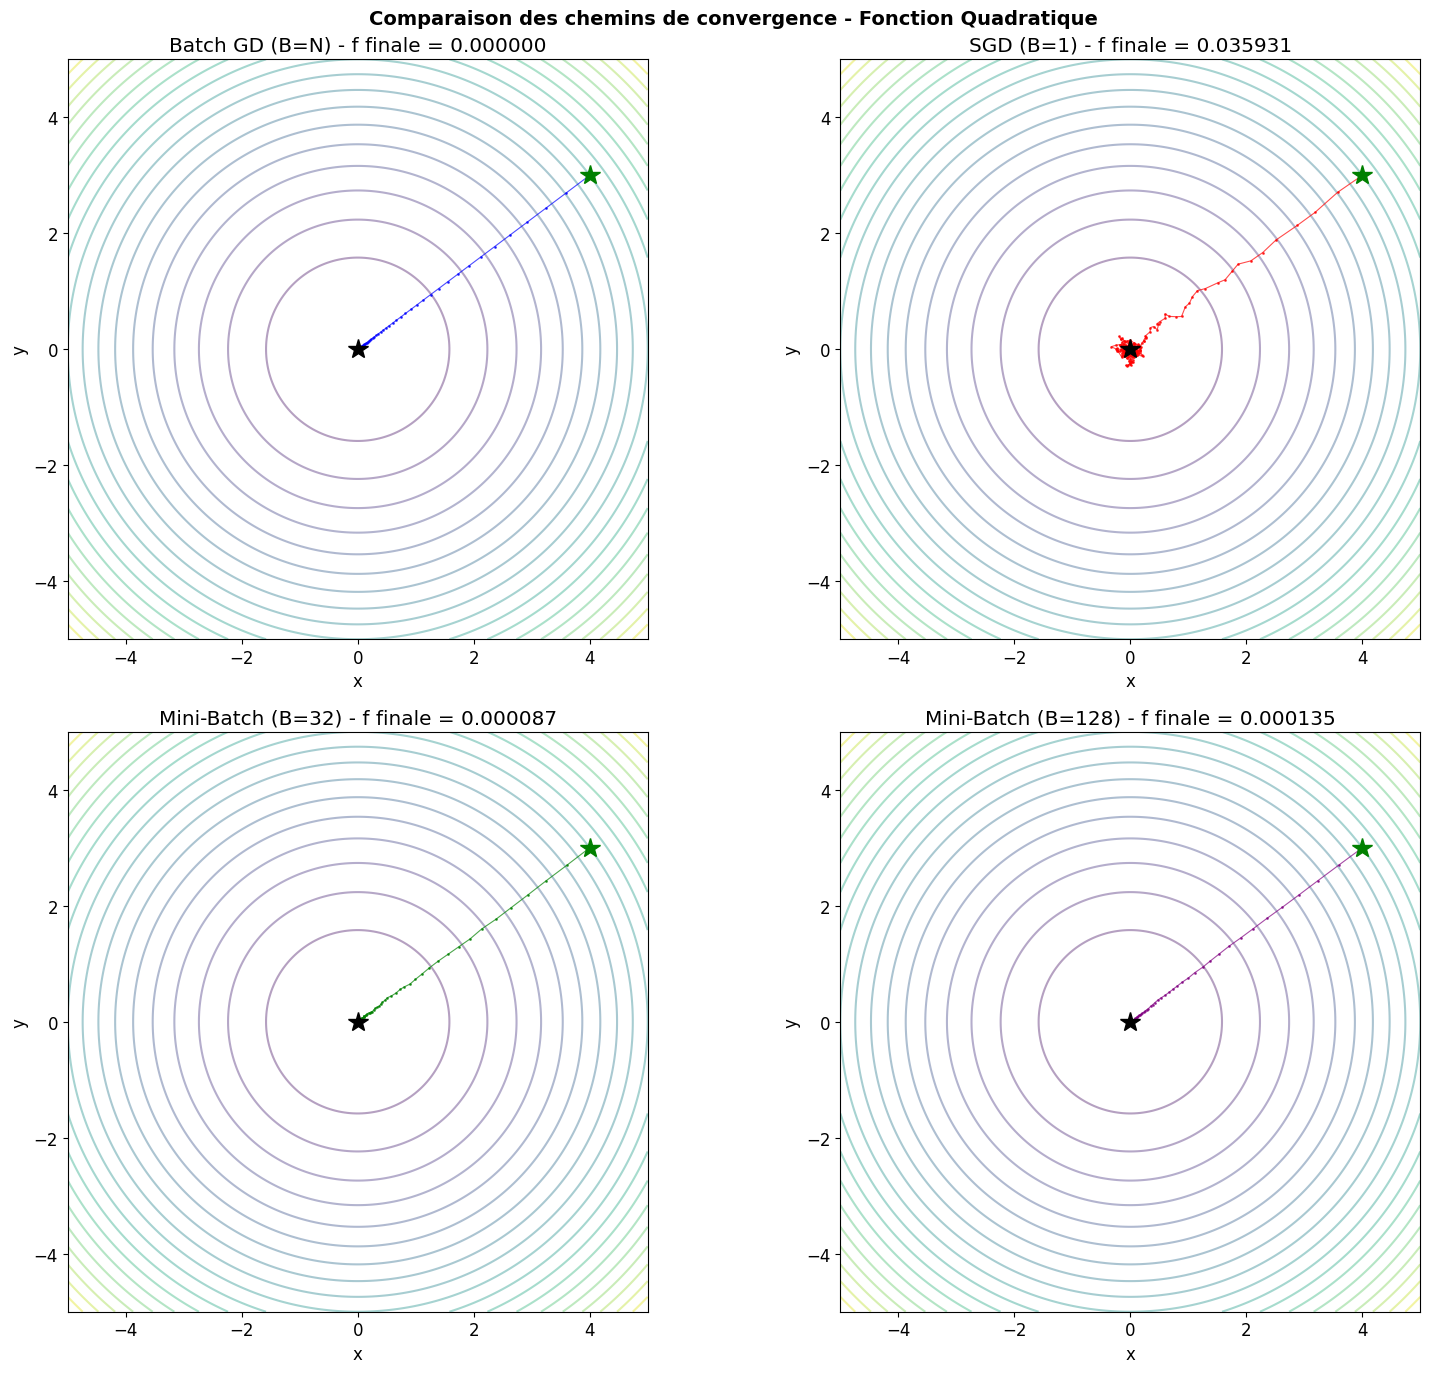

In [5]:
# Grande figure comparative
x_range = np.linspace(-5, 5, 200)
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

methods = [
    ('Batch GD (B=N)', path_bgd, 'blue'),
    ('SGD (B=1)', path_sgd, 'red'),
    ('Mini-Batch (B=32)', path_mb32, 'green'),
    ('Mini-Batch (B=128)', path_mb128, 'purple')
]

for ax, (name, path, color) in zip(axes.flat, methods):
    path_arr = np.array(path)
    ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.4)
    ax.plot(path_arr[:, 0], path_arr[:, 1], color=color, marker='.', markersize=2,
            linewidth=0.8, alpha=0.7)
    ax.plot(path_arr[0, 0], path_arr[0, 1], 'g*', markersize=15)
    ax.plot(0, 0, 'k*', markersize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{name} - f finale = {f_simple(path[-1]):.6f}')
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

plt.suptitle('Comparaison des chemins de convergence - Fonction Quadratique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

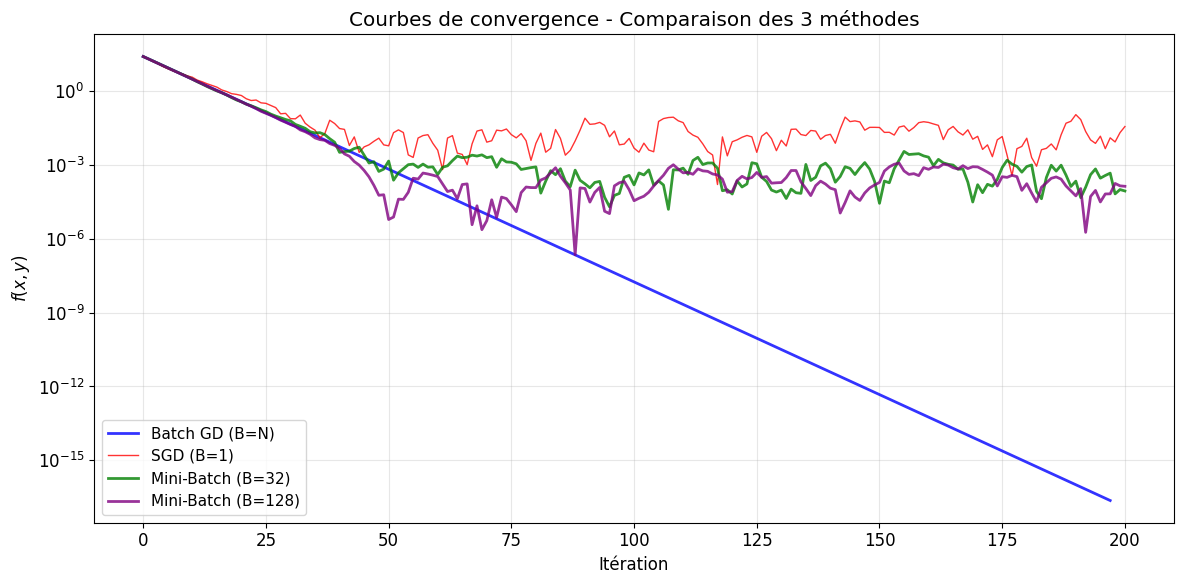

Observation : Le Mini-Batch GD offre un compromis entre la stabilité du Batch GD
et la rapidité du SGD. Plus le batch est grand, plus la courbe est lisse.


In [6]:
# Courbes de convergence comparatives
fig, ax = plt.subplots(figsize=(12, 6))

for name, path, color in methods:
    f_vals = [f_simple(p) for p in path]
    lw = 2 if 'Batch' in name else 1
    ax.plot(f_vals, color=color, linewidth=lw, alpha=0.8, label=name)

ax.set_xlabel('Itération')
ax.set_ylabel('$f(x, y)$')
ax.set_title('Courbes de convergence - Comparaison des 3 méthodes')
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation : Le Mini-Batch GD offre un compromis entre la stabilité du Batch GD")
print("et la rapidité du SGD. Plus le batch est grand, plus la courbe est lisse.")

### Étude de l'effet de la taille du batch

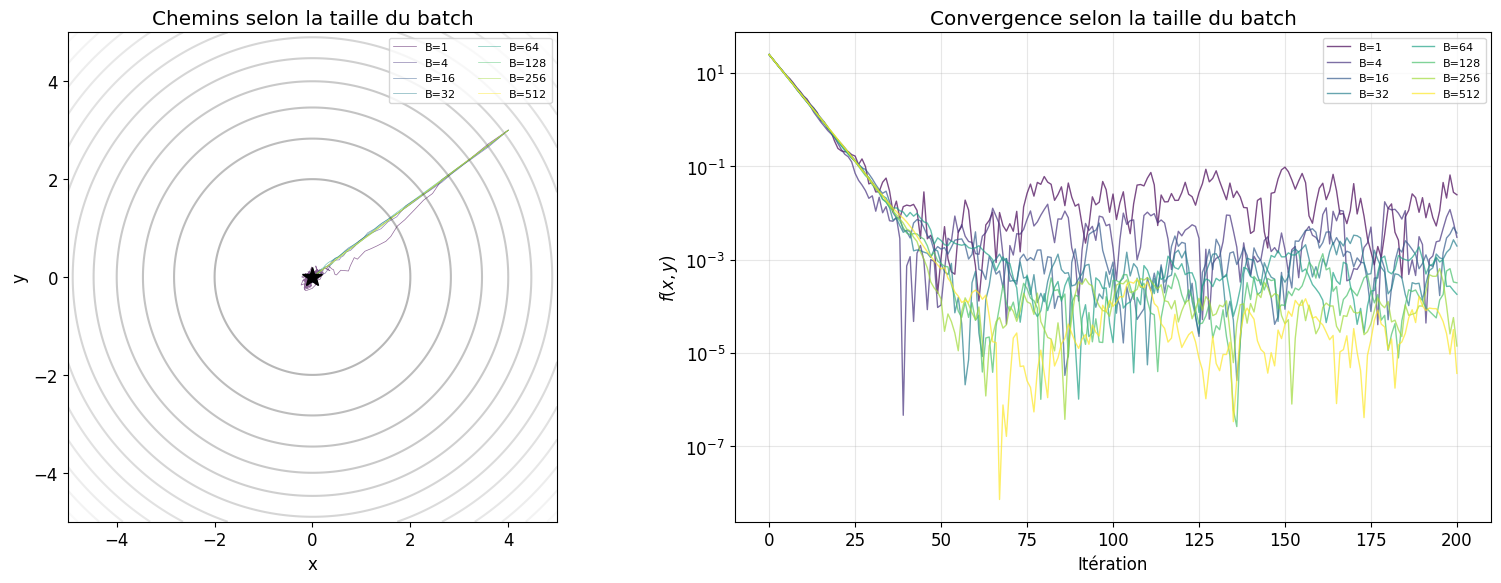

In [7]:
batch_sizes = [1, 4, 16, 32, 64, 128, 256, 512]
colors = plt.cm.viridis(np.linspace(0, 1, len(batch_sizes)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

final_values = []

for bs, color in zip(batch_sizes, colors):
    if bs == 1:
        path = sgd_optimize(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter, noise_scale=1.0)
    else:
        path = mini_batch_gd_optimize(grad_simple, x_init, learning_rate=lr, n_iterations=n_iter, batch_size=bs)

    f_vals = [f_simple(p) for p in path]
    final_values.append(f_vals[-1])

    path_arr = np.array(path)
    axes[0].plot(path_arr[:, 0], path_arr[:, 1], color=color, linewidth=0.5, alpha=0.6, label=f'B={bs}')
    axes[1].plot(f_vals, color=color, linewidth=1, alpha=0.7, label=f'B={bs}')

axes[0].contour(X, Y, Z, levels=15, cmap='gray', alpha=0.3)
axes[0].plot(0, 0, 'k*', markersize=15)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Chemins selon la taille du batch')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_aspect('equal')

axes[1].set_xlabel('Itération')
axes[1].set_ylabel('$f(x,y)$')
axes[1].set_title('Convergence selon la taille du batch')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

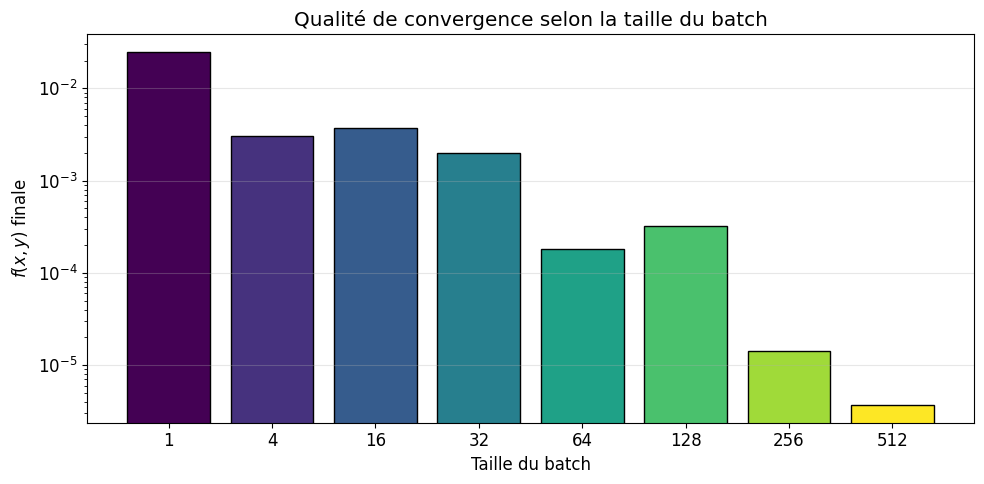

Plus le batch est grand, plus la convergence est précise (moins de bruit).


In [8]:
# Valeur finale en fonction de la taille du batch
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(batch_sizes)), final_values, color=colors, edgecolor='black')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(bs) for bs in batch_sizes])
ax.set_xlabel('Taille du batch')
ax.set_ylabel('$f(x,y)$ finale')
ax.set_title('Qualité de convergence selon la taille du batch')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Plus le batch est grand, plus la convergence est précise (moins de bruit).")

## 5. Fonction Complexe : Fonction de Rosenbrock

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

In [9]:
def f_rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dfdx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dfdy = 200 * (x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

In [10]:
x_init_rosen = np.array([-1.5, 1.5])
n_iter_rosen = 8000
lr_rosen = 0.001

# Trois méthodes sur la Rosenbrock
path_bgd_r = batch_gradient_descent(grad_rosenbrock, x_init_rosen,
                                      learning_rate=lr_rosen, n_iterations=n_iter_rosen)
path_sgd_r = sgd_optimize(grad_rosenbrock, x_init_rosen,
                           learning_rate=lr_rosen*0.5, n_iterations=n_iter_rosen, noise_scale=0.3)
path_mb32_r = mini_batch_gd_optimize(grad_rosenbrock, x_init_rosen,
                                      learning_rate=lr_rosen, n_iterations=n_iter_rosen, batch_size=32)
path_mb128_r = mini_batch_gd_optimize(grad_rosenbrock, x_init_rosen,
                                       learning_rate=lr_rosen, n_iterations=n_iter_rosen, batch_size=128)

print(f"{'Méthode':<20} {'Point final':>25} {'f finale':>15}")
print("-" * 65)
for name, path in [('Batch GD', path_bgd_r), ('SGD (B=1)', path_sgd_r),
                     ('Mini-batch (B=32)', path_mb32_r), ('Mini-batch (B=128)', path_mb128_r)]:
    print(f"{name:<20} [{path[-1][0]:>9.5f}, {path[-1][1]:>9.5f}] {f_rosenbrock(path[-1]):>15.8f}")

Méthode                            Point final        f finale
-----------------------------------------------------------------
Batch GD             [  0.98040,   0.96111]      0.00038460
SGD (B=1)            [  0.88314,   0.77989]      0.01365551
Mini-batch (B=32)    [  0.98493,   0.96943]      0.00027082
Mini-batch (B=128)   [  0.97988,   0.96010]      0.00040518


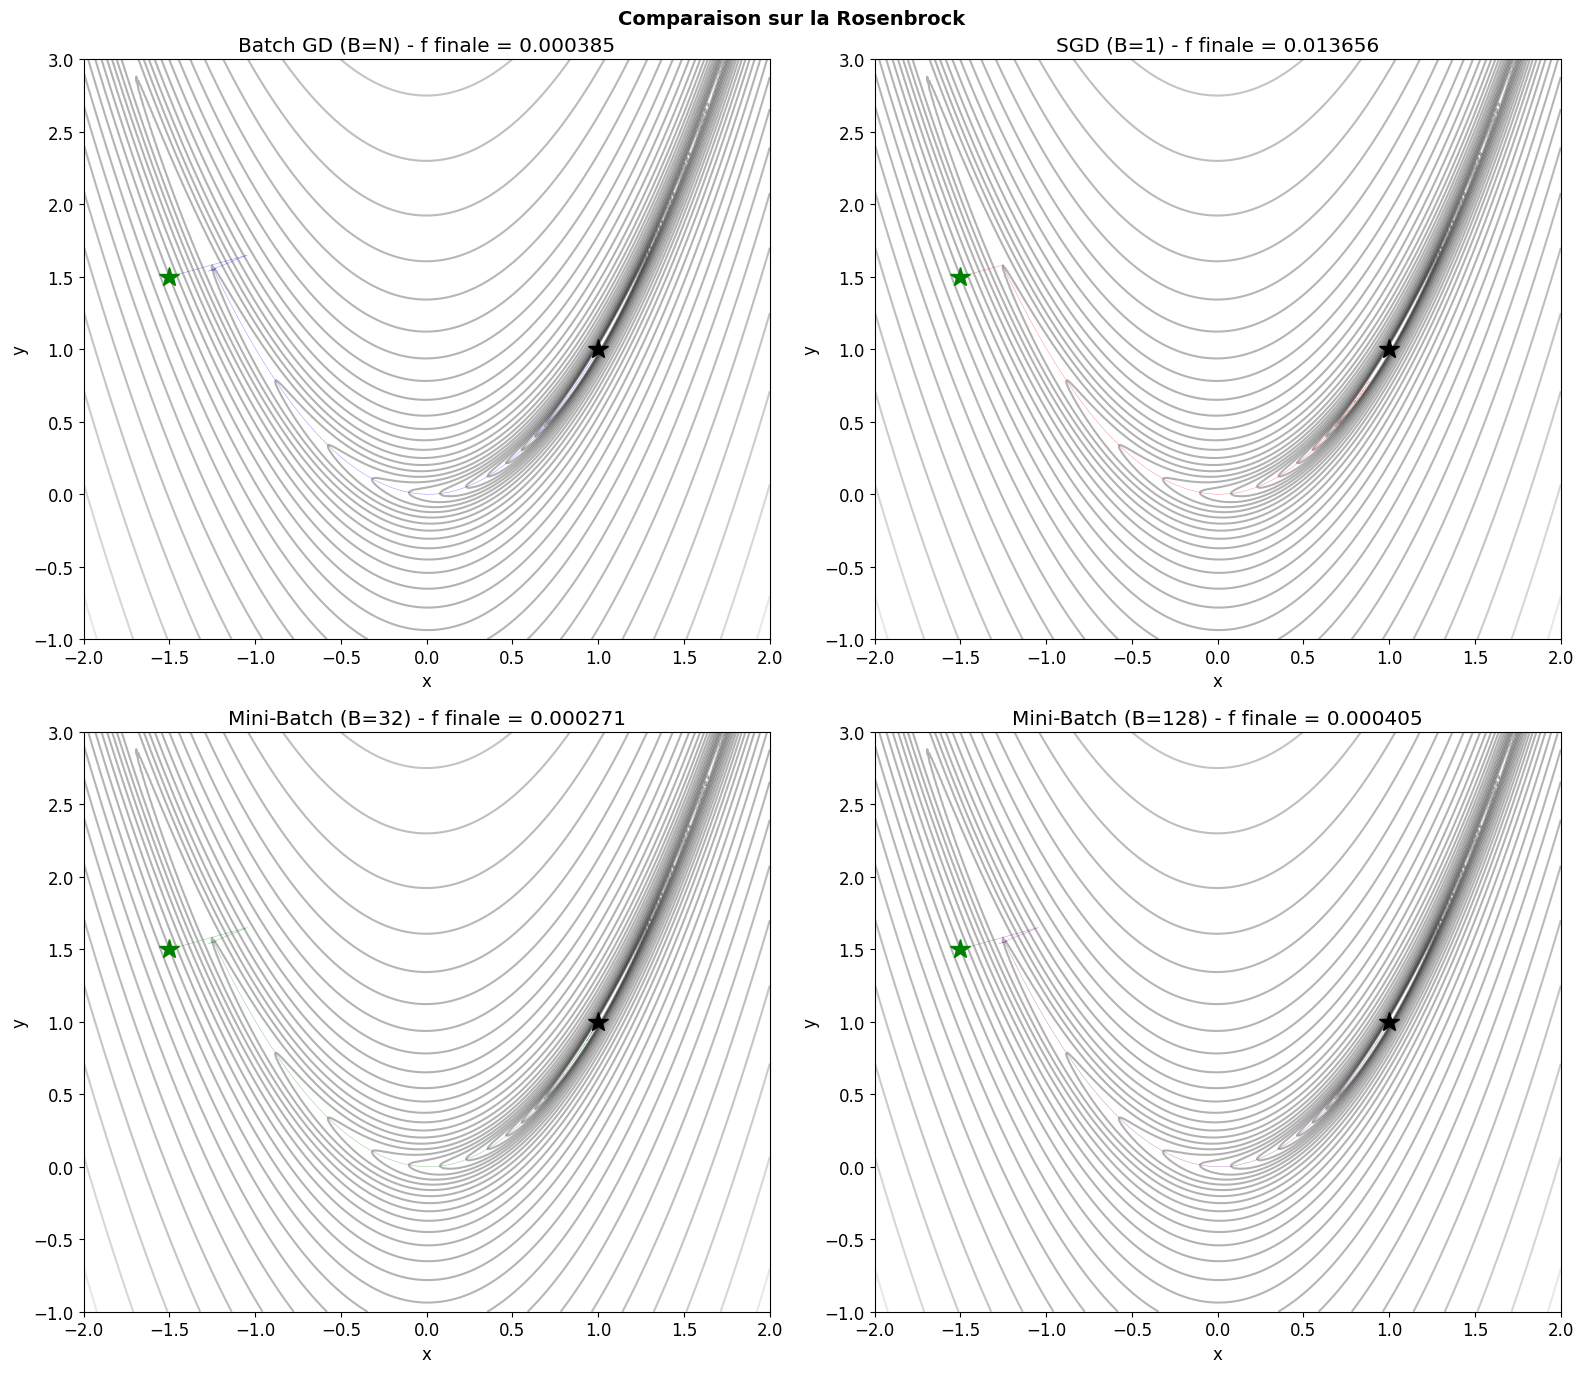

In [11]:
# Visualisation Rosenbrock
x_range_r = np.linspace(-2, 2, 300)
y_range_r = np.linspace(-1, 3, 300)
Xr, Yr = np.meshgrid(x_range_r, y_range_r)
Zr = (1 - Xr)**2 + 100 * (Yr - Xr**2)**2
levels = np.logspace(-1, 3.5, 30)

methods_r = [
    ('Batch GD (B=N)', path_bgd_r, 'blue'),
    ('SGD (B=1)', path_sgd_r, 'red'),
    ('Mini-Batch (B=32)', path_mb32_r, 'green'),
    ('Mini-Batch (B=128)', path_mb128_r, 'purple')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, path, color) in zip(axes.flat, methods_r):
    path_arr = np.array(path)
    ax.contour(Xr, Yr, Zr, levels=levels, cmap='gray', alpha=0.3)
    ax.plot(path_arr[:, 0], path_arr[:, 1], color=color, linewidth=0.3, alpha=0.5)
    ax.plot(path_arr[0, 0], path_arr[0, 1], 'g*', markersize=15)
    ax.plot(1, 1, 'k*', markersize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{name} - f finale = {f_rosenbrock(path[-1]):.6f}')

plt.suptitle('Comparaison sur la Rosenbrock', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

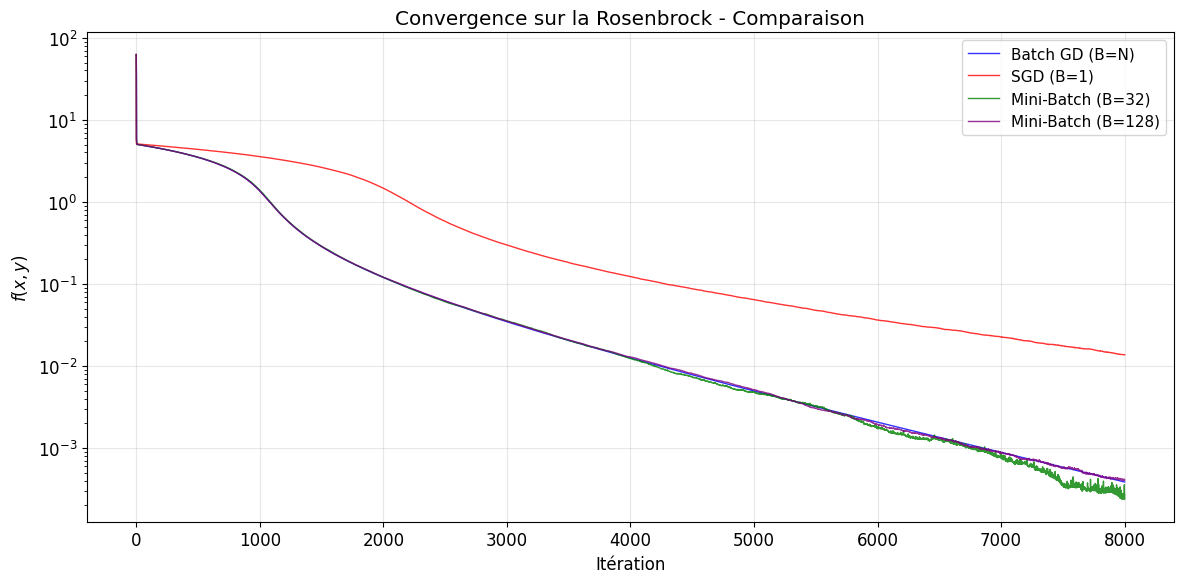

In [12]:
# Courbes de convergence Rosenbrock
fig, ax = plt.subplots(figsize=(12, 6))

for name, path, color in methods_r:
    f_vals = [f_rosenbrock(p) for p in path]
    ax.plot(f_vals, color=color, linewidth=1, alpha=0.8, label=name)

ax.set_xlabel('Itération')
ax.set_ylabel('$f(x, y)$')
ax.set_title('Convergence sur la Rosenbrock - Comparaison')
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Application : Classification avec Régression Logistique (Mini-Batch GD)

Implémentation from scratch avec le **vrai** comportement mini-batch : à chaque itération, on échantillonne un sous-ensemble de $B$ exemples.

In [13]:
class LogisticRegressionMiniBatch:
    """
    Régression Logistique optimisée par Mini-Batch Gradient Descent.
    À chaque itération, on utilise un sous-ensemble de B exemples.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100, batch_size=32):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        """
        Entraînement par Mini-Batch Gradient Descent.

        Pour chaque époque :
        1. Mélanger les données
        2. Découper en mini-batches de taille B
        3. Pour chaque mini-batch, calculer le gradient et mettre à jour
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.n_epochs):
            # Mélanger les indices
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Découper en mini-batches
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                X_batch = X_shuffled[start:end]  # Mini-batch de features
                y_batch = y_shuffled[start:end]   # Mini-batch de labels
                batch_size_actual = end - start

                # === FORWARD PASS sur le mini-batch ===
                z = X_batch @ self.weights + self.bias
                y_pred = self._sigmoid(z)

                # === GRADIENT sur le mini-batch ===
                error = y_pred - y_batch
                dw = (1 / batch_size_actual) * (X_batch.T @ error)
                db = (1 / batch_size_actual) * np.sum(error)

                # === MISE À JOUR ===
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            # Loss sur tout le dataset à la fin de chaque époque
            y_pred_all = self._sigmoid(X @ self.weights + self.bias)
            loss = self._compute_loss(y, y_pred_all)
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Génération des données

In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 800 échantillons
Test  : 200 échantillons


### Entraînement avec différentes tailles de batch

In [15]:
# On implémente aussi les deux autres méthodes pour comparer
class LogisticRegressionBGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    def _compute_loss(self, y, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
        return -np.mean(y * np.log(y_pred) + (1-y) * np.log(1-y_pred))
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        for i in range(self.n_iterations):
            y_pred = self._sigmoid(X @ self.weights + self.bias)
            self.loss_history.append(self._compute_loss(y, y_pred))
            error = y_pred - y
            self.weights -= self.learning_rate * (1/n_samples) * (X.T @ error)
            self.bias -= self.learning_rate * (1/n_samples) * np.sum(error)
        return self
    def predict(self, X, threshold=0.5):
        return (self._sigmoid(X @ self.weights + self.bias) >= threshold).astype(int)

class LogisticRegressionSGD:
    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    def _compute_loss(self, y, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
        return -np.mean(y * np.log(y_pred) + (1-y) * np.log(1-y_pred))
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        t = 0
        for epoch in range(self.n_epochs):
            for i in np.random.permutation(n_samples):
                lr = self.learning_rate / (1 + 0.001 * t)
                y_pred_i = self._sigmoid(np.dot(X[i], self.weights) + self.bias)
                error = y_pred_i - y[i]
                self.weights -= lr * X[i] * error
                self.bias -= lr * error
                t += 1
            y_pred_all = self._sigmoid(X @ self.weights + self.bias)
            self.loss_history.append(self._compute_loss(y, y_pred_all))
        return self
    def predict(self, X, threshold=0.5):
        return (self._sigmoid(X @ self.weights + self.bias) >= threshold).astype(int)

In [16]:
n_epochs = 100
lr_class = 0.5

# Batch GD
model_bgd = LogisticRegressionBGD(learning_rate=lr_class, n_iterations=n_epochs)
model_bgd.fit(X_train, y_train)

# SGD
model_sgd = LogisticRegressionSGD(learning_rate=lr_class, n_epochs=n_epochs)
model_sgd.fit(X_train, y_train)

# Mini-Batch avec différentes tailles
batch_sizes_test = [16, 32, 64, 128, 256]
models_mb = {}
for bs in batch_sizes_test:
    model = LogisticRegressionMiniBatch(learning_rate=lr_class, n_epochs=n_epochs, batch_size=bs)
    model.fit(X_train, y_train)
    models_mb[bs] = model

print("Entraînement terminé pour toutes les méthodes !")

Entraînement terminé pour toutes les méthodes !


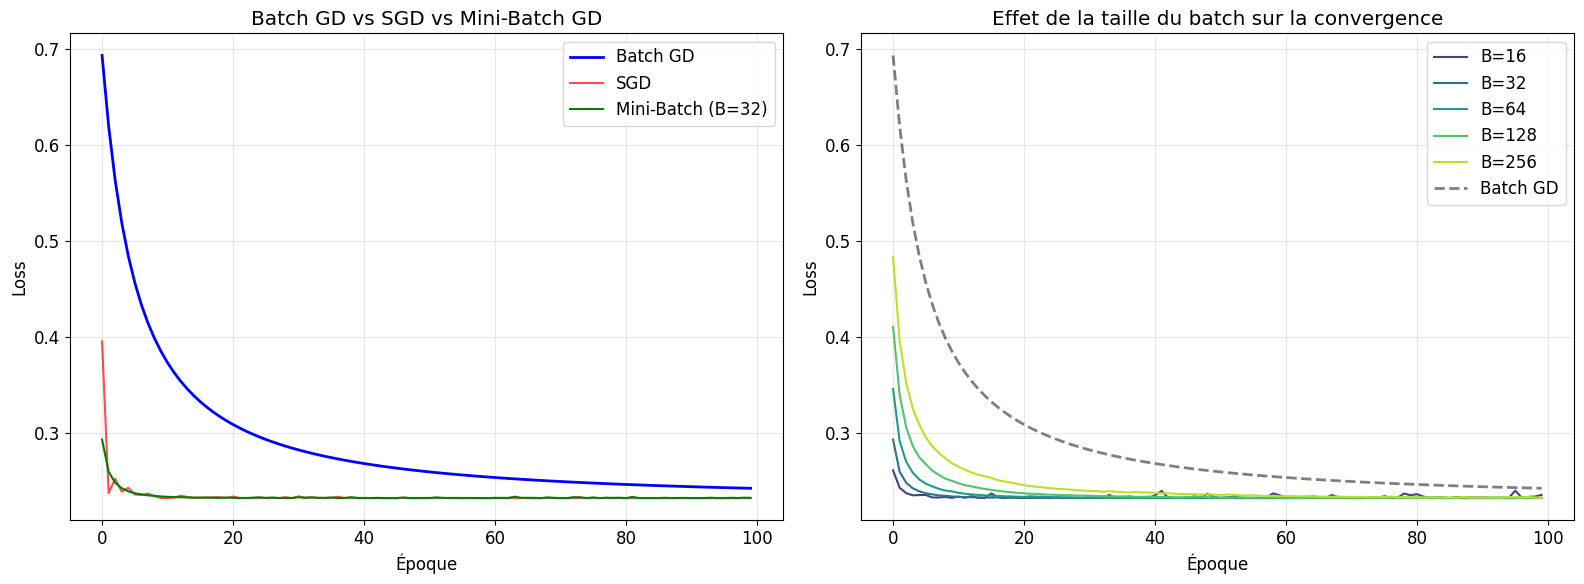

In [17]:
# Courbes d'entraînement comparatives
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Figure 1 : Batch GD vs SGD vs Mini-Batch (B=32) ---
ax1 = axes[0]
ax1.plot(model_bgd.loss_history, 'b-', linewidth=2, label='Batch GD')
ax1.plot(model_sgd.loss_history, 'r-', linewidth=1.5, alpha=0.7, label='SGD')
ax1.plot(models_mb[32].loss_history, 'g-', linewidth=1.5, label='Mini-Batch (B=32)')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.set_title('Batch GD vs SGD vs Mini-Batch GD')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Figure 2 : Effet de la taille du batch ---
ax2 = axes[1]
colors_mb = plt.cm.viridis(np.linspace(0.2, 0.9, len(batch_sizes_test)))
for bs, color in zip(batch_sizes_test, colors_mb):
    ax2.plot(models_mb[bs].loss_history, color=color, linewidth=1.5, label=f'B={bs}')
ax2.plot(model_bgd.loss_history, 'k--', linewidth=2, alpha=0.5, label='Batch GD')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Loss')
ax2.set_title('Effet de la taille du batch sur la convergence')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Frontières de décision

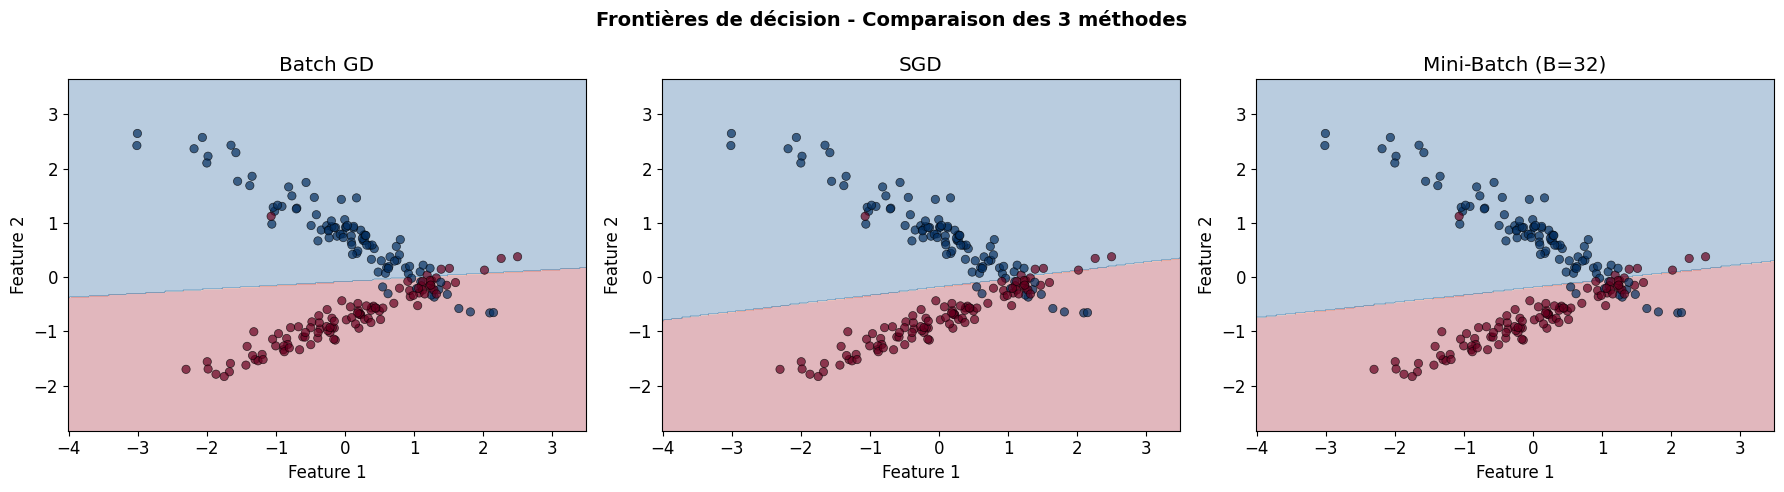

In [18]:
def plot_decision_boundary(model, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(model_bgd, X_test, y_test, axes[0], 'Batch GD')
plot_decision_boundary(model_sgd, X_test, y_test, axes[1], 'SGD')
plot_decision_boundary(models_mb[32], X_test, y_test, axes[2], 'Mini-Batch (B=32)')
plt.suptitle('Frontières de décision - Comparaison des 3 méthodes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Métriques d'Évaluation Complètes

In [19]:
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def compute_all_metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

In [20]:
# Tableau comparatif complet
all_models = {
    'Batch GD': model_bgd,
    'SGD': model_sgd,
}
for bs in batch_sizes_test:
    all_models[f'Mini-Batch (B={bs})'] = models_mb[bs]

print("=" * 75)
print("COMPARAISON COMPLÈTE DES MÉTRIQUES")
print("=" * 75)
print(f"{'Méthode':<25} {'Accuracy':>10} {'Precision':>11} {'Recall':>10} {'F1-Score':>10}")
print("-" * 70)

results = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    metrics = compute_all_metrics(y_test, y_pred)
    results[name] = metrics
    print(f"{name:<25} {metrics['Accuracy']:>10.4f} {metrics['Precision']:>11.4f} {metrics['Recall']:>10.4f} {metrics['F1-Score']:>10.4f}")

COMPARAISON COMPLÈTE DES MÉTRIQUES
Méthode                     Accuracy   Precision     Recall   F1-Score
----------------------------------------------------------------------
Batch GD                      0.8950      0.9213     0.8542     0.8865
SGD                           0.9000      0.9222     0.8646     0.8925
Mini-Batch (B=16)             0.8800      0.8750     0.8750     0.8750
Mini-Batch (B=32)             0.9000      0.9222     0.8646     0.8925
Mini-Batch (B=64)             0.9000      0.9222     0.8646     0.8925
Mini-Batch (B=128)            0.9000      0.9222     0.8646     0.8925
Mini-Batch (B=256)            0.9000      0.9222     0.8646     0.8925


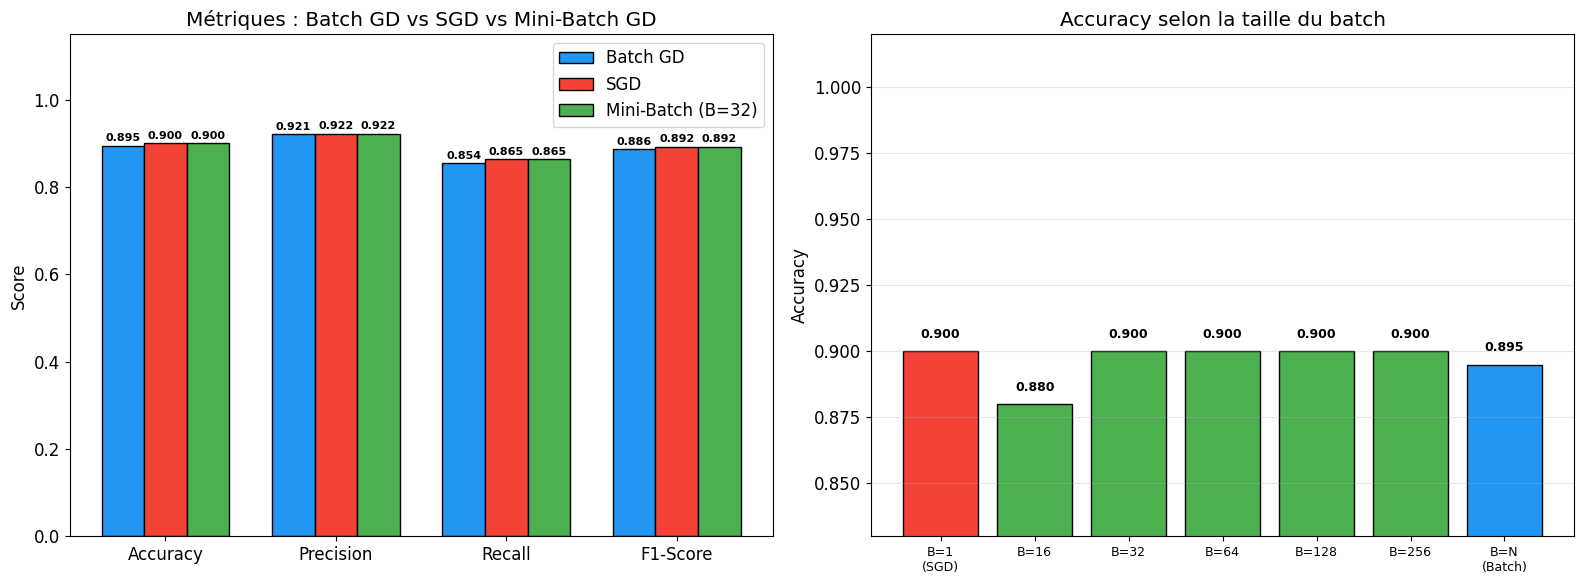

In [21]:
# Visualisation radar/bar chart des métriques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart groupé : 3 méthodes principales ---
ax1 = axes[0]
methods_main = ['Batch GD', 'SGD', 'Mini-Batch (B=32)']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(metric_names))
width = 0.25
colors_main = ['#2196F3', '#F44336', '#4CAF50']

for idx, (method, color) in enumerate(zip(methods_main, colors_main)):
    values = [results[method][m] for m in metric_names]
    bars = ax1.bar(x_pos + idx * width, values, width, label=method, color=color, edgecolor='black')
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(metric_names)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.set_title('Métriques : Batch GD vs SGD vs Mini-Batch GD')
ax1.legend()

# --- Accuracy en fonction de la taille du batch ---
ax2 = axes[1]
batch_labels = ['B=1\n(SGD)'] + [f'B={bs}' for bs in batch_sizes_test] + [f'B=N\n(Batch)']
acc_values = [results['SGD']['Accuracy']] + \
             [results[f'Mini-Batch (B={bs})']['Accuracy'] for bs in batch_sizes_test] + \
             [results['Batch GD']['Accuracy']]

colors_bar = ['#F44336'] + ['#4CAF50'] * len(batch_sizes_test) + ['#2196F3']
ax2.bar(range(len(batch_labels)), acc_values, color=colors_bar, edgecolor='black')
ax2.set_xticks(range(len(batch_labels)))
ax2.set_xticklabels(batch_labels, fontsize=9)
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy selon la taille du batch')
ax2.set_ylim(min(acc_values) - 0.05, 1.02)
ax2.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(acc_values):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

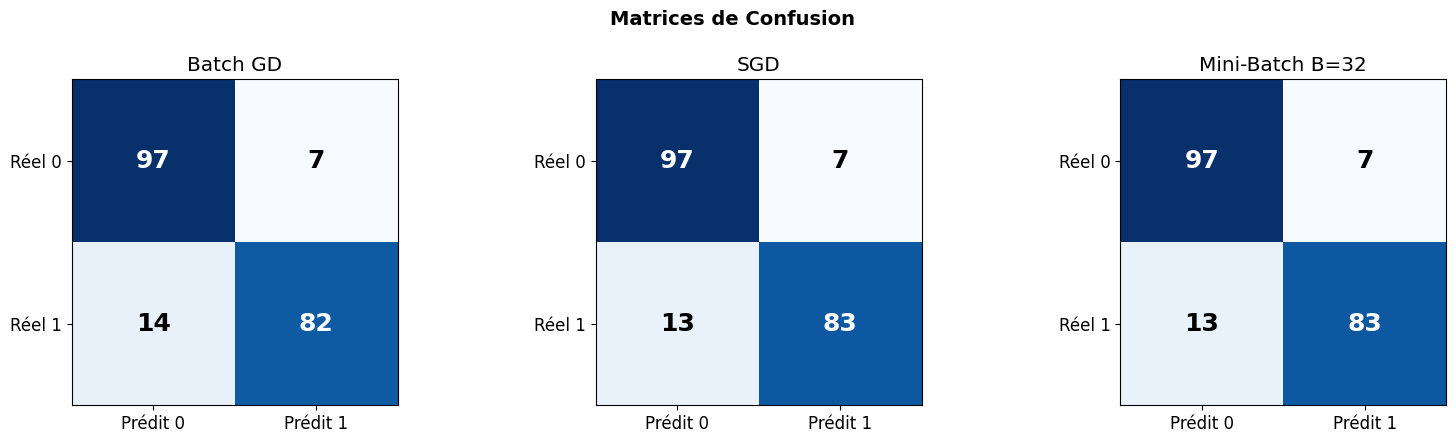

In [22]:
# Matrices de confusion pour les 3 méthodes principales
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, model) in zip(axes, [('Batch GD', model_bgd), ('SGD', model_sgd), ('Mini-Batch B=32', models_mb[32])]):
    y_pred = model.predict(X_test)
    tp, tn, fp, fn = confusion_matrix_manual(y_test, y_pred)
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Prédit 0', 'Prédit 1'])
    ax.set_yticklabels(['Réel 0', 'Réel 1'])
    ax.set_title(name)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.suptitle('Matrices de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Tableau Récapitulatif Final

### Comparaison des 3 méthodes de Gradient Descent

| Critère | Batch GD | SGD | Mini-Batch GD |
|---|---|---|---|
| **Données par mise à jour** | Tout le dataset ($N$) | 1 exemple | $B$ exemples ($1 < B < N$) |
| **Mises à jour par époque** | 1 | $N$ | $N/B$ |
| **Stabilité** | Très stable | Très bruitée | Modérément stable |
| **Vitesse par itération** | Lente | Très rapide | Rapide |
| **Mémoire** | Élevée | Faible | Moyenne |
| **Parallélisable (GPU)** | Oui | Non | Oui |
| **Minima locaux** | Peut rester bloqué | Peut s'échapper | Compromis |
| **Utilisation pratique** | Petits datasets | Online learning | **Standard en Deep Learning** |

## 9. Conclusion

### Ce qu'on a appris :
1. Le **Mini-Batch GD** est le **compromis idéal** entre Batch GD et SGD
2. La **taille du batch** contrôle le compromis bruit/stabilité :
   - Petit batch (16-32) : plus de bruit, peut aider à la généralisation
   - Grand batch (128-256) : plus stable, convergence plus lisse
3. En pratique, le Mini-Batch GD est **la méthode standard** utilisée dans le Deep Learning
4. Les trois méthodes arrivent à des performances de classification **similaires**, mais diffèrent en vitesse et stabilité de convergence
5. Le choix de la taille du batch est un hyperparamètre à optimiser selon le problème

### Recommandations pratiques :
- Commencez avec $B = 32$ (bon compromis par défaut)
- Si la convergence est trop bruitée, augmentez $B$
- Si l'entraînement est trop lent, diminuez $B$
- Utilisez toujours la **normalisation** des features (StandardScaler)
- Considérez un **learning rate schedule** pour améliorer la convergence